# 05: Execution-based metrics

Does the translation preserve semantics? Oracle = the gold **SQL on Postgres**; compared against the generated query run on the graph DB, as multisets (Execution Accuracy / precision / recall / F1 / Jaccard). Prerequisites:

- graphonauts **Postgres** up (port 5433, db/user `graphonaut`) loaded with LDBC SF1.
- **Neo4j** up (`bolt://localhost:7687`, `NEO4J_PASSWORD`) loaded with LDBC SF1 (Cypher target).
- **ArangoDB** up (`http://localhost:8529`, db **`graphonauts`**, `ARANGO_PASSWORD`) loaded with LDBC SF1 (AQL target). **After every (re)load run `eval/scripts/build_arango_unified_edges.py`** to build the mapping-aligned unified edge collections (`KNOWS`, `HAS_CREATOR`, `HAS_TAG`, ...); without them every AQL traversal errors and execution accuracy is 0.
- **Gremlin Server** up (`ws://localhost:8182/gremlin`, TraversalSource `g`) with graphonauts's in-memory TinkerGraph loaded (Gremlin target). TinkerGraph lives on the JVM heap: run it with Neo4j and ArangoDB **stopped**, and reload after any container restart (`uv run graphonauts load gremlin` in graphonauts; see its `docs/gremlin/LOADING_BRIEF.md`).
- **Datetime**: Neo4j stores `creationDate`/`birthday`/`joinDate` as native temporals; ArangoDB and TinkerGraph store them as ISO-8601 strings. Both are reconciled to epoch-millis by `harness.execution.to_epoch_ms` against the columns the Postgres oracle reports as dates.

Because the graph DBs cannot all run at once (memory), execution is **per target**: `EVAL_EXECUTION_TARGETS` (default `cypher,aql,gremlin`) selects which targets execute this pass, and the save cell **merges** into `metrics_execution.csv` so the other targets' rows are preserved. Export the passwords for the backends you run (`NEO4J_PASSWORD` / `ARANGO_PASSWORD` / `POSTGRES_PASSWORD`); they are asserted lazily per target. Comparison is **positional** (RETURN column order must match the SQL SELECT order). Cypher, AQL, and Gremlin results are reported in separate subsections below (never mixed).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import json
import os

import pandas as pd
from harness import EXECUTION_CACHE_PATH, METRICS_EXECUTION_CSV, RECORDS_DIR, load_records

OUT_CSV = METRICS_EXECUTION_CSV
CACHE_PATH = EXECUTION_CACHE_PATH
from harness import plots

## Connection configs and DB availability map

Which `(dataset, target)` cells can be executed: the dataset needs a Postgres oracle, the target needs a graph DB. `cypher` runs on Neo4j, `aql` on ArangoDB (db `graphonauts`). DB passwords are asserted lazily per target on first use, so a Cypher-only or AQL-only subset needs only that backend up.

In [2]:
from harness import execution as ex

# Connection config, the comparator, and the per-backend executors live in
# harness.execution, shared with eval/scripts/validate_gold.py. Targets executed
# THIS pass; every other target's rows in metrics_execution.csv are preserved by
# the merge in the save cell (the backends cannot all run at once).
EXEC_TARGETS = [t.strip() for t in os.environ.get('EVAL_EXECUTION_TARGETS', 'cypher,aql,gremlin').split(',') if t.strip()]
print(f'Backends: {ex.TARGET_DB} | per-query timeout: {ex.TIMEOUT_S}s | executing: {EXEC_TARGETS}')


Backends: {'cypher': 'neo4j', 'aql': 'arangodb', 'gremlin': 'gremlin'} | per-query timeout: 180s | executing: ['cypher', 'aql', 'gremlin']


## Comparator and executors

The row normalisation, the date-reconciling multiset comparator, and the per-backend
executors (including the Gremlin daemon-thread-per-query workaround) live in
`harness.execution`, shared with `eval/scripts/validate_gold.py` so the gold proof and
the model scoring can never drift. Passwords are asserted lazily per target on first
use, so a subset run only needs that backend up.

## Reference-row cache

Keyed by `(dataset, query_id)` so the same query id across datasets does not collide. Delete `execution_rows_cache.json` to refresh.

In [3]:
cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
print(f'Reference cache: {len(cache)} entries.')

Reference cache: 14 entries.


## Execution, per target

One `execute_target(target)` call runs every record of that target against its graph DB and returns the metric rows; the model subsections below slice that frame per model. A target not listed in `EVAL_EXECUTION_TARGETS` is skipped (returns `None`) and keeps its existing rows in `metrics_execution.csv`.

In [4]:
records = load_records(RECORDS_DIR)
print(f'Loaded {len(records)} record(s); targets selected for execution: {EXEC_TARGETS}')

def execute_target(target):
    """Execute every record of one target; returns the metric rows (None if skipped)."""
    if target not in EXEC_TARGETS:
        print(f'{target}: skipped (not in EVAL_EXECUTION_TARGETS); existing rows are preserved.')
        return None
    return ex.execute_records(records, target, cache, CACHE_PATH)

EXEC_COLS = ['query_id', 'difficulty', 'execution_accuracy', 'result_precision', 'result_recall',
             'result_f1', 'result_jaccard_dist', 'execution_error', 'translated_runtime_s',
             'reference_rows', 'translated_rows']
EXEC_METRIC_COLS = ['execution_accuracy', 'result_precision', 'result_recall', 'result_f1', 'result_jaccard_dist']

def show_model(frame, model):
    """Per-query execution results for one model (frame = one target's metric rows)."""
    if frame is None:
        print('Target skipped this pass.')
        return None
    sub = frame[frame['model'] == model]
    if not len(sub):
        print(f'No executed records for {model}.')
        return None
    return sub[EXEC_COLS].sort_values('query_id').reset_index(drop=True)

def summarize_target(frame):
    """Mean execution metrics by model (frame = one target's metric rows)."""
    if frame is None:
        print('Target skipped this pass.')
        return None
    return frame.groupby('model')[EXEC_METRIC_COLS].mean()


Loaded 180 record(s); targets selected for execution: ['cypher', 'aql', 'gremlin']


## SQL → Cypher

In [5]:
cypher_exec_df = execute_target('cypher')

cypher: 60 executable record(s).
[  1/60] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/60] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/60] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/60] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/60] ldbc_q05 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[  6/60] ldbc_q06 (cypher) ok EX=1 F1=1.00 ref=5 trans=5
[  7/60] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/60] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/60] ldbc_q09 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/60] ldbc_q10 (cypher) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/60] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/60] ldbc_q12 (cypher) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/60] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/60] ldbc_q14 (cypher) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/60] ldbc_q15 (cypher) ok EX=1 F1=1.00 ref=3 trans=3
[ 16/60] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[ 17/

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `tag_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=4, column=34, offset=115>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 115, 'line': 4, 'column': 34}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (t:Tag)\nWITH t, COLLECT(DISTINCT {tag_id: t.id}) as tags\nUNWIND tags AS tag\nOPTIONAL MATCH (mt:Tag) WHERE mt.tag_id = tag.tag_id\nRETURN t.id, t.name, COUNT(DISTINCT mt) as usage_count\nORDER BY usage_count DESC\nLIMIT 20'


ne EX=0 F1=0.00 ref=20 trans=20
[ 36/60] ldbc_q06 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `person_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=26, offset=53>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 53, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p1:Person {id: 933})\nOPTIONAL MATCH (k:Knows {person_id: p1.id})\nOPTIONAL MATCH (p2:Person {id: k.friend_id})\nRETURN p2.id, p2.firstName, p2.lastName, k.creationDate AS friendship_date'
Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `K

ne EX=0 F1=0.00 ref=5 trans=1
[ 37/60] ldbc_q07 (cypher) 

...

ne EX=0 F1=0.00 ref=20 trans=0
[ 55/60] ldbc_q10 (cypher) ne EX=0 F1=0.12 ref=90492 trans=90492
[ 56/60] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 57/60] ldbc_q12 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `forum_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=10, offset=52>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 52, 'line': 2, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Person)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 137439023186\nRETURN DISTINCT p.id, p.firstName, p.lastName\nUNION\nMATCH (p:Person)-[:LIKES]->(l:Post)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 137439023186\nRETURN DISTINCT p.id, p.firstName, p.lastName'
Received notification from DBMS server: <GqlStatusObject g

ne EX=0 F1=0.00 ref=917 trans=0
[ 58/60] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 59/60] ldbc_q14 (cypher) ne EX=0 F1=0.00 ref=111 trans=0
[ 60/60] ldbc_q15 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=2, column=1, offset=26>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 26, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Place {id: 111})\nCALL {\n    WITH p\n    MATCH path = (p)-[:IS_PART_OF*]->(descendant:Place)\n    UNWIND nodes(path) AS node\n    WITH DISTINCT node\n    RETURN node.id AS id, node.name AS name, node.type AS type, 1 AS depth\n}\nWITH p\nMATCH path = (p)-[:IS_PART_OF*]->(descendant:Place)\nUNWIND nodes(path) AS node\nWITH DISTINCT no

ne EX=0 F1=0.33 ref=3 trans=3


### llama3.2:latest

In [6]:
show_model(cypher_exec_df, 'llama3.2:latest')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.005899,1,1
1,ldbc_q02,easy,0.0,0.000000,0.000000,0.000000,1.00000,CypherSyntaxError: {neo4j_code: Neo.ClientErro...,0.023628,12932,0
2,ldbc_q03,easy,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.067277,4,0
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,2.769803,10,10
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.00000,NaN,23.217693,20,20
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.103707,5,1
6,ldbc_q07,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.134743,58,0
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.00000,NaN,1.468818,2805,0
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.110812,20,0
9,ldbc_q10,hard,0.0,0.121801,0.121801,0.121801,0.93515,NaN,5.299337,90492,90492


### qwen3-coder:30b

In [7]:
show_model(cypher_exec_df, 'qwen3-coder:30b')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.051670,1,1
1,ldbc_q02,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,1.800318,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.010715,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,1.073776,10,10
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.00000,ClientError: {neo4j_code: Neo.ClientError.Tran...,181.250236,20,0
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.051799,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.029078,58,58
7,ldbc_q08,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.346619,2805,2805
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.185082,20,0
9,ldbc_q10,hard,0.0,0.121801,0.121801,0.121801,0.93515,NaN,5.041742,90492,90492


### gemma4:26b

In [8]:
show_model(cypher_exec_df, 'gemma4:26b')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.012680,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,NaN,1.984065,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.015474,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,NaN,3.022830,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,NaN,2.615813,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.079643,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.173931,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,NaN,0.267071,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.122344,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,NaN,5.727353,90492,90492


### claude-opus-4-8

In [9]:
show_model(cypher_exec_df, 'claude-opus-4-8')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,NaN,2.286016,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,NaN,2.404421,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.176129,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,NaN,5.551313,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,NaN,5.308004,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.144708,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.243003,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,NaN,0.764024,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.206831,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,NaN,7.118999,90492,90492


### Visualizations

SQL -> Cypher: 4 model(s), 15 query id(s)


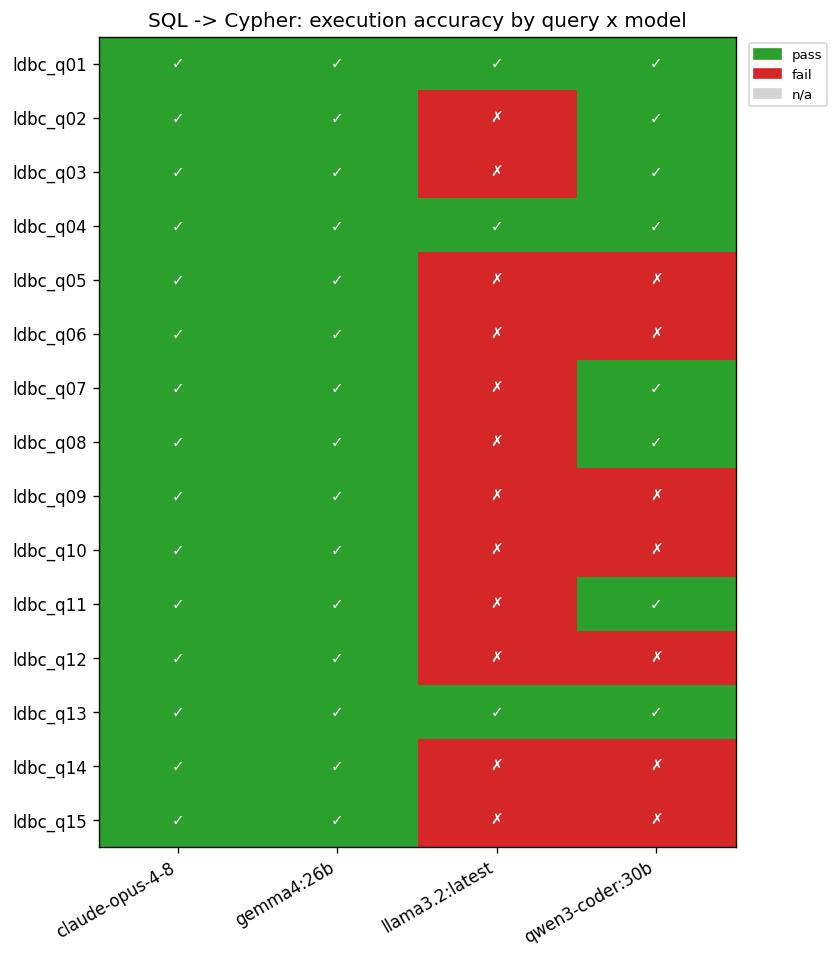

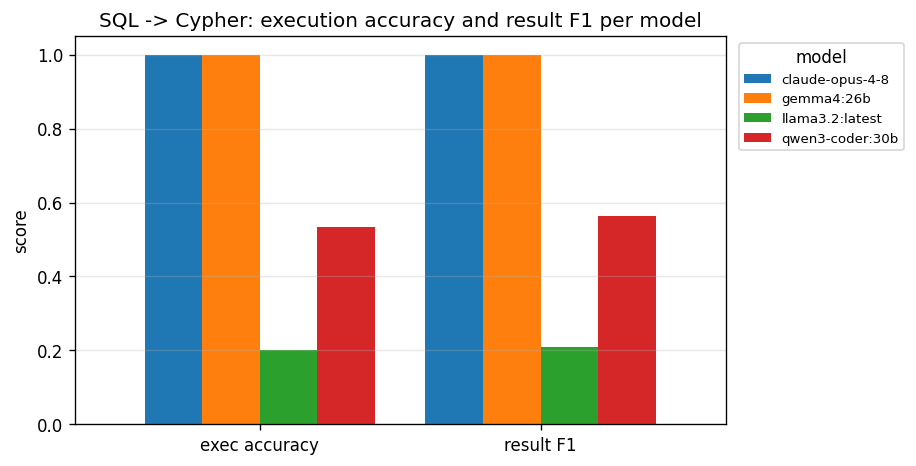

In [10]:
plots.render_target(cypher_exec_df, 'cypher', 'SQL -> Cypher', plots.FIGURE_SETS['execution'])

### Aggregation by model

In [11]:
summarize_target(cypher_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
claude-opus-4-8,1.000000,1.000000,1.000000,1.000000,0.000000
gemma4:26b,1.000000,1.000000,1.000000,1.000000,0.000000
llama3.2:latest,0.200000,0.208120,0.208120,0.208120,0.795677
qwen3-coder:30b,0.533333,0.563676,0.563676,0.563676,0.449010


## SQL → AQL

In [18]:
aql_exec_df = execute_target('aql')

aql: 60 executable record(s).
[  1/60] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/60] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/60] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/60] ldbc_q04 (aql) ok EX=1 F1=1.00 ref=10 trans=10
[  5/60] ldbc_q05 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[  6/60] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/60] ldbc_q07 (aql) ok EX=1 F1=1.00 ref=58 trans=58
[  8/60] ldbc_q08 (aql) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/60] ldbc_q09 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/60] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/60] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/60] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/60] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/60] ldbc_q14 (aql) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/60] ldbc_q15 (aql) ok EX=1 F1=1.00 ref=3 trans=3
[ 16/60] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[ 17/60] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12

### llama3.2:latest

In [19]:
show_model(aql_exec_df, 'llama3.2:latest')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003351,1,0
1,ldbc_q02,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004210,12932,0
2,ldbc_q03,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003386,4,0
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003651,10,0
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 400][ERR 1512] use...,0.003284,20,0
5,ldbc_q06,medium,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003356,5,0
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003801,58,0
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004276,2805,0
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
9,ldbc_q10,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004491,90492,0


### qwen3-coder:30b

In [20]:
show_model(aql_exec_df, 'qwen3-coder:30b')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.006663,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.105949,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.006632,4,4
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,NaN,21.489706,10,10
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,NaN,0.136216,20,0
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.006914,5,5
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,NaN,0.014516,58,58
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,NaN,61.253760,2805,21084
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,NaN,6.115437,20,0
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,NaN,16.717188,90492,90492


### gemma4:26b

In [21]:
show_model(aql_exec_df, 'gemma4:26b')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.006701,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.101441,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.006573,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,NaN,0.914472,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,NaN,45.827661,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.006629,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.010652,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,NaN,28.442576,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,NaN,56.170957,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,NaN,1.679498,90492,90492


### claude-opus-4-8

In [22]:
show_model(aql_exec_df, 'claude-opus-4-8')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.008599,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.118763,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,NaN,0.006061,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,NaN,14.473389,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,NaN,114.353099,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.006422,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,NaN,0.009947,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,NaN,25.005602,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,NaN,50.004296,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,NaN,16.102578,90492,90492


### Visualizations

SQL -> AQL: 4 model(s), 15 query id(s)


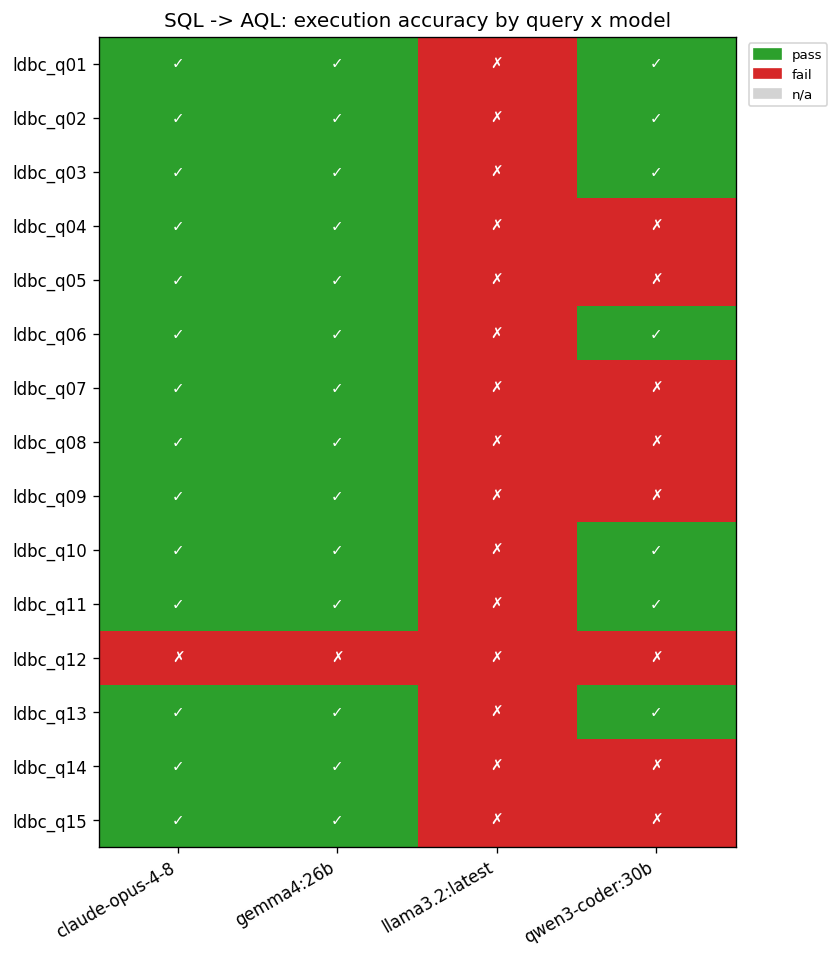

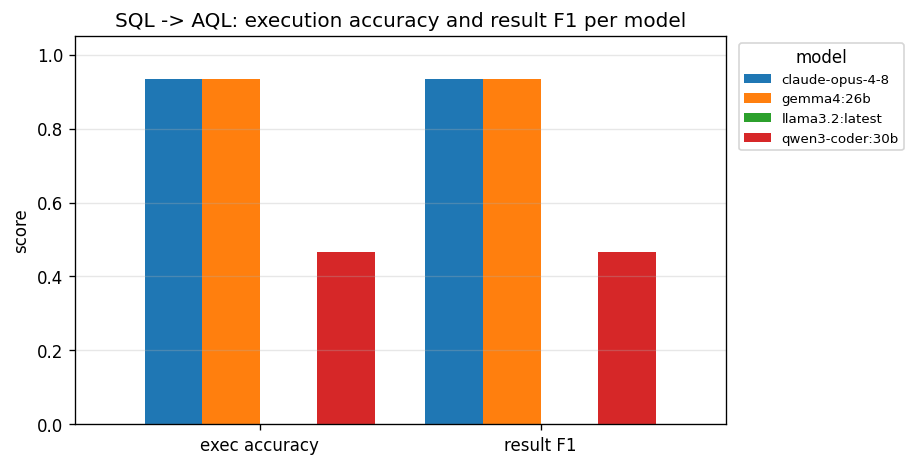

In [23]:
plots.render_target(aql_exec_df, 'aql', 'SQL -> AQL', plots.FIGURE_SETS['execution'])

### Aggregation by model

In [24]:
summarize_target(aql_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
claude-opus-4-8,0.933333,0.933333,0.933333,0.933333,0.066667
gemma4:26b,0.933333,0.933333,0.933333,0.933333,0.066667
llama3.2:latest,0.000000,0.000000,0.000000,0.000000,1.000000
qwen3-coder:30b,0.466667,0.466667,0.466667,0.466667,0.533333


## SQL → Gremlin

In [25]:
gremlin_exec_df = execute_target('gremlin')

gremlin: 60 executable record(s).
[  1/60] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/60] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/60] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/60] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[  5/60] ldbc_q05 (gremlin) ne EX=0 F1=0.05 ref=20 trans=20
[  6/60] ldbc_q06 (gremlin) ne EX=0 F1=0.00 ref=5 trans=5
[  7/60] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[  8/60] ldbc_q08 (gremlin) ne EX=0 F1=0.00 ref=2805 trans=2423
[  9/60] ldbc_q09 (gremlin) ne EX=0 F1=0.00 ref=20 trans=20
[ 10/60] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/60] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/60] ldbc_q12 (gremlin) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/60] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/60] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 15/60] ldbc_q15 (gremlin) EXEC ERROR (KeyError: <DataType.tree: 43>)
[ 16/60] ldbc_q01 (gremlin) 

Exception ignored in: <function AiohttpTransport.__del__ at 0x1224c4f40>
Traceback (most recent call last):
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 67, in __del__
    self.close()
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 138, in close
    self._loop.run_until_complete(async_close())
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 667, in run_until_complete
    self._check_running()
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 628, in _check_running
    raise RuntimeError(
RuntimeError: Cannot run the event loop while another loop is running
/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/l

ok EX=1 F1=1.00 ref=1 trans=1
[ 17/60] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[ 18/60] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[ 19/60] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[ 20/60] ldbc_q05 (gremlin) ne EX=0 F1=0.05 ref=20 trans=20
[ 21/60] ldbc_q06 (gremlin) ok EX=1 F1=1.00 ref=5 trans=5
[ 22/60] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[ 23/60] ldbc_q08 (gremlin) ne EX=0 F1=0.15 ref=2805 trans=35270
[ 24/60] ldbc_q09 (gremlin) ok EX=1 F1=1.00 ref=20 trans=20
[ 25/60] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 26/60] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 27/60] ldbc_q12 (gremlin) ne EX=0 F1=1.00 ref=917 trans=916
[ 28/60] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 29/60] ldbc_q14 (gremlin) ok EX=1 F1=1.00 ref=111 trans=111
[ 30/60] ldbc_q15 (gremlin) ne EX=0 F1=0.00 ref=3 trans=2
[ 31/60] ldbc_q01 (gremlin) ne EX=0 F1=0.00 ref=1 trans=0
[ 32/60] ldbc_q02 (gremlin) skip (translation inv


Received error message '{'requestId': '1331e8f1-da51-48cf-9d50-3bc86e09d9bf', 'status': {'code': 598, 'message': "Evaluation exceeded the configured 'evaluationTimeout' threshold of 180000 ms or evaluation was otherwise cancelled directly for request [g.V().has('id', 933)\n    .out('KNOWS').in('KNOWS')\n    .out('KNOWS').in('KNOWS')\n    .out('STUDY_AT').in('STUDY_AT')\n    .out('HAS_INTEREST').in('HAS_INTEREST')\n    .out('HAS_INTEREST').in('HAS_INTEREST')\n    .out('HAS_INTEREST').in('HAS_INTEREST')\n    .project('id', 'firstName', 'lastName', 'sharedTag')\n        .by('id')\n        .by('firstName')\n        .by('lastName')\n        .by('name')\n    .dedup()]", 'attributes': {'stackTrace': "java.util.concurrent.TimeoutException: Evaluation exceeded the configured 'evaluationTimeout' threshold of 180000 ms or evaluation was otherwise cancelled directly for request [g.V().has('id', 933)\n    .out('KNOWS').in('KNOWS')\n    .out('KNOWS').in('KNOWS')\n    .out('STUDY_AT').in('STUDY_AT')

EXEC ERROR (GremlinServerError: 598: Evaluation exceeded the configured )
[ 39/60] ldbc_q09 (gremlin) skip (translation invalid)
[ 40/60] ldbc_q10 (gremlin) skip (translation invalid)
[ 41/60] ldbc_q11 (gremlin) skip (translation invalid)
[ 42/60] ldbc_q12 (gremlin) skip (translation invalid)
[ 43/60] ldbc_q13 (gremlin) skip (translation invalid)
[ 44/60] ldbc_q14 (gremlin) skip (translation invalid)
[ 45/60] ldbc_q15 (gremlin) skip (translation invalid)
[ 46/60] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[ 47/60] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[ 48/60] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[ 49/60] ldbc_q04 (gremlin) 

...

ne EX=0 F1=0.00 ref=20 trans=0
[ 51/60] ldbc_q06 (gremlin) ne EX=0 F1=0.00 ref=5 trans=5
[ 52/60] ldbc_q07 (gremlin) ne EX=0 F1=0.00 ref=58 trans=0
[ 53/60] ldbc_q08 (gremlin) skip (translation invalid)
[ 54/60] ldbc_q09 (gremlin) ne EX=0 F1=0.00 ref=20 trans=0
[ 55/60] ldbc_q10 (gremlin) 


Received error message '{'requestId': '8dd17e13-e968-49b8-8937-8da652207315', 'status': {'code': 597, 'message': 'The by("member_count") modulator can only be applied to a traverser that is an Element or a Map - it is being applied to [5] a Long class instead', 'attributes': {'stackTrace': 'java.lang.IllegalStateException: The by("member_count") modulator can only be applied to a traverser that is an Element or a Map - it is being applied to [5] a Long class instead\n\tat org.apache.tinkerpop.gremlin.process.traversal.lambda.ValueTraversal.addStart(ValueTraversal.java:114)\n\tat org.apache.tinkerpop.gremlin.process.traversal.util.TraversalUtil.prepare(TraversalUtil.java:186)\n\tat org.apache.tinkerpop.gremlin.process.traversal.util.TraversalUtil.produce(TraversalUtil.java:108)\n\tat org.apache.tinkerpop.gremlin.process.traversal.step.map.OrderGlobalStep.createProjectedTraverser(OrderGlobalStep.java:183)\n\tat org.apache.tinkerpop.gremlin.process.traversal.step.map.OrderGlobalStep.proc

EXEC ERROR (GremlinServerError: 597: The by("member_count") modulator ca)
[ 56/60] ldbc_q11 (gremlin) 

Exception ignored in: <function AiohttpTransport.__del__ at 0x1224c4f40>
Traceback (most recent call last):
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 67, in __del__
    self.close()
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 138, in close
    self._loop.run_until_complete(async_close())
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 667, in run_until_complete
    self._check_running()
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 628, in _check_running
    raise RuntimeError(
RuntimeError: Cannot run the event loop while another loop is running
/Users/ivona.obonova/school/rows2graph/rows2graph/eval/harness/execution.py:340

skip (translation invalid)
[ 57/60] ldbc_q12 (gremlin) skip (translation invalid)
[ 58/60] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 59/60] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 60/60] ldbc_q15 (gremlin) skip (translation invalid)


### llama3.2:latest

In [26]:
show_model(gremlin_exec_df, 'llama3.2:latest')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,0.0,0.0,0.0,0.0,1.0,NaN,0.028324,1,0
1,ldbc_q02,easy,0.0,0.0,0.0,0.0,1.0,NaN,NaN,12932,0
2,ldbc_q03,easy,0.0,0.0,0.0,0.0,1.0,NaN,0.741394,4,0
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,10,0
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
5,ldbc_q06,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,5,0
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,58,0
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,GremlinServerError: 598: Evaluation exceeded t...,180.126275,2805,0
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
9,ldbc_q10,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,90492,0


### qwen3-coder:30b

In [27]:
show_model(gremlin_exec_df, 'qwen3-coder:30b')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.370451,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,NaN,1.666656,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.724419,4,4
3,ldbc_q04,hard,0.0,0.000000,0.000000,0.000000,1.000000,"GremlinServerError: 597: The by(""member_count""...",23.208019,10,0
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.959626,20,0
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,0.777287,5,5
6,ldbc_q07,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.349627,58,0
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,NaN,2805,0
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.086028,20,0
9,ldbc_q10,hard,0.0,0.000000,0.000000,0.000000,1.000000,"GremlinServerError: 597: The by(""member_count""...",0.780273,90492,0


### gemma4:26b

In [28]:
show_model(gremlin_exec_df, 'gemma4:26b')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.065769,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,NaN,4.566811,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.938594,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.666935,10,10
4,ldbc_q05,hard,0.0,0.050000,0.050000,0.050000,0.974359,NaN,3.124650,20,20
5,ldbc_q06,medium,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.838889,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.617202,58,58
7,ldbc_q08,hard,0.0,0.079529,1.000000,0.147341,0.920471,NaN,3.032517,2805,35270
8,ldbc_q09,medium,1.0,1.000000,1.000000,1.000000,0.000000,NaN,9.287430,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,4.110306,90492,90492


### claude-opus-4-8

In [29]:
show_model(gremlin_exec_df, 'claude-opus-4-8')

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,19.468517,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,NaN,10.854444,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.709888,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,12.070139,10,10
4,ldbc_q05,hard,0.0,0.050000,0.050000,0.050000,0.974359,NaN,5.828321,20,20
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,0.826214,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.851758,58,58
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,8.225792,2805,2423
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,20.041234,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,10.345158,90492,90492


### Visualizations

SQL -> Gremlin: 4 model(s), 15 query id(s)


Exception ignored in: <function AiohttpTransport.__del__ at 0x1224c4f40>
Traceback (most recent call last):
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 67, in __del__
    self.close()
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 138, in close
    self._loop.run_until_complete(async_close())
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 667, in run_until_complete
    self._check_running()
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 628, in _check_running
    raise RuntimeError(
RuntimeError: Cannot run the event loop while another loop is running
/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-pac

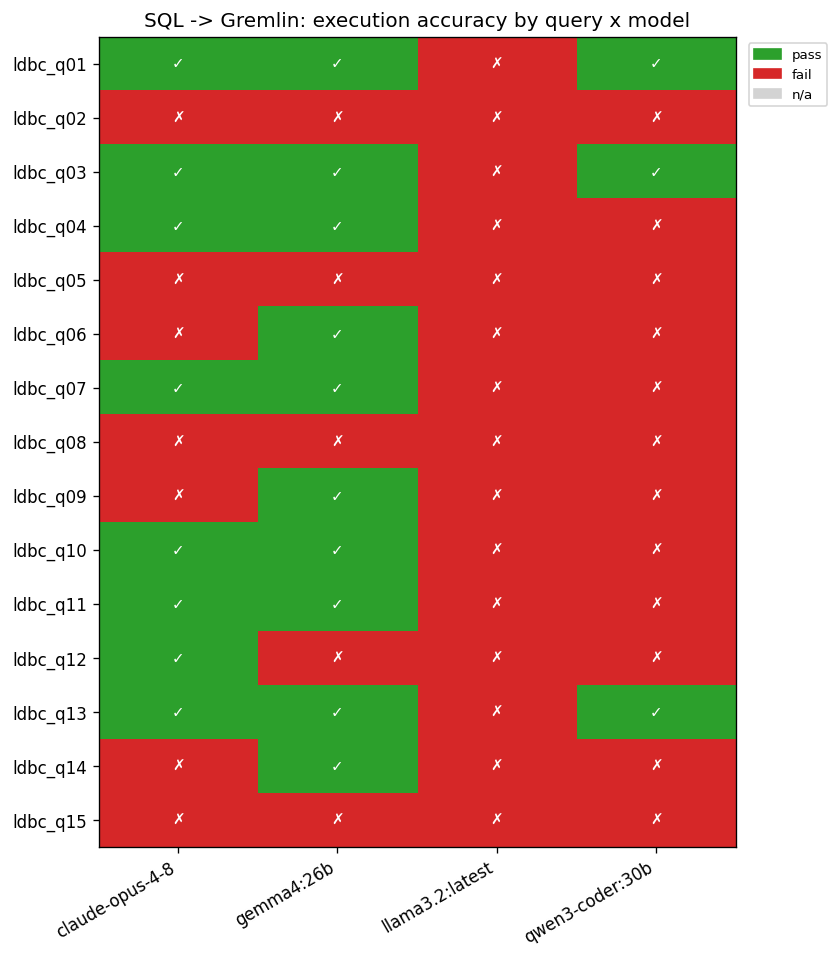

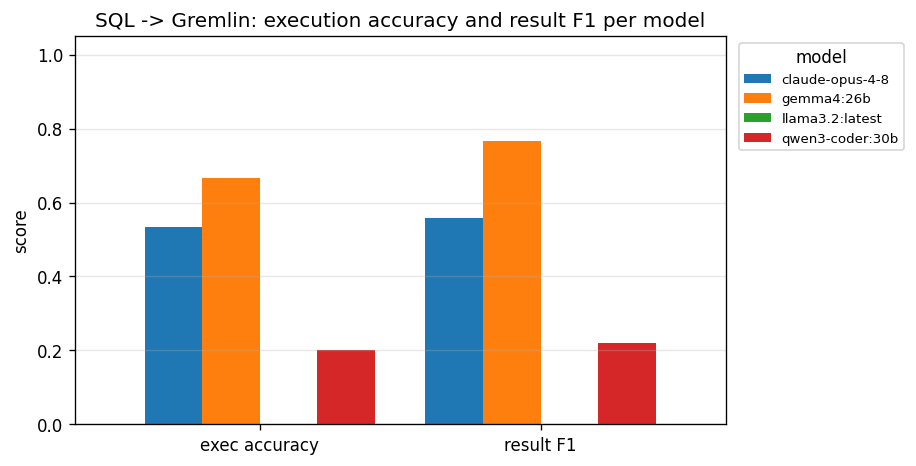

In [30]:
plots.render_target(gremlin_exec_df, 'gremlin', 'SQL -> Gremlin', plots.FIGURE_SETS['execution'])

### Aggregation by model

In [31]:
summarize_target(gremlin_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
claude-opus-4-8,0.533333,0.557669,0.557669,0.557669,0.452493
gemma4:26b,0.666667,0.762971,0.824263,0.767455,0.247264
llama3.2:latest,0.000000,0.000000,0.000000,0.000000,1.000000
qwen3-coder:30b,0.200000,0.221002,0.221002,0.221002,0.787536


## Run-level summary and save

Merges this pass's per-target frames into `metrics_execution.csv`: rows belonging to targets that were executed are replaced, all other targets' rows are kept as-is.

In [32]:
new_frames = {t: f for t, f in (('cypher', cypher_exec_df), ('aql', aql_exec_df),
                                ('gremlin', gremlin_exec_df)) if f is not None}
if OUT_CSV.exists():
    exec_all = pd.read_csv(OUT_CSV)
    exec_all = exec_all[~exec_all['target'].isin(new_frames)]
else:
    exec_all = pd.DataFrame()
frames = ([exec_all] if len(exec_all) else []) + [f for f in new_frames.values() if len(f)]
exec_all = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

metric_cols = ['execution_accuracy','result_precision','result_recall','result_f1','result_jaccard_dist']
if len(exec_all):
    print('By dataset x target x model:')
    display(exec_all.groupby(['dataset','target','model'])[metric_cols].mean())
exec_all.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(exec_all)} rows to {OUT_CSV} "
      f"(executed this pass: {', '.join(new_frames) or 'none'}; other targets' rows preserved).")
ex.close_clients()

By dataset x target x model:


execution_accuracy  result_precision  \
dataset target  model                                                   
ldbc    aql     claude-opus-4-8            0.933333          0.933333   
                gemma4:26b                 0.933333          0.933333   
                llama3.2:latest            0.000000          0.000000   
                qwen3-coder:30b            0.466667          0.466667   
        cypher  claude-opus-4-8            1.000000          1.000000   
                gemma4:26b                 1.000000          1.000000   
                llama3.2:latest            0.200000          0.208120   
                qwen3-coder:30b            0.533333          0.563676   
        gremlin claude-opus-4-8            0.533333          0.557669   
                gemma4:26b                 0.666667          0.762971   
                llama3.2:latest            0.000000          0.000000   
                qwen3-coder:30b            0.200000          0.221002   

                                 result_recall  result_f1  result_jaccard_dist  
dataset target  model                                                           
ldbc    aql     claude-opus-4-8       0.933333   0.933333             0.066667  
                gemma4:26b            0.933333   0.933333             0.066667  
                llama3.2:latest       0.000000   0.000000             1.000000  
                qwen3-coder:30b       0.466667   0.466667             0.533333  
        cypher  claude-opus-4-8       1.000000   1.000000             0.000000  
                gemma4:26b            1.000000   1.000000             0.000000  
                llama3.2:latest       0.208120   0.208120             0.795677  
                qwen3-coder:30b       0.563676   0.563676             0.449010  
        gremlin claude-opus-4-8       0.557669   0.557669             0.452493  
                gemma4:26b            0.824263   0.767455             0.247264  
                llama3.2:latest       0.000000   0.000000             1.000000  
                qwen3-coder:30b       0.221002   0.221002             0.787536

Wrote 180 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/eval/outputs/metrics/metrics_execution.csv (executed this pass: cypher, aql, gremlin; other targets' rows preserved).
